#Day26. 머신러닝기초
---


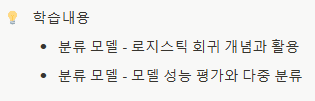

##**k-NN 알고리즘**

1. **거리 측정**: 새로운 데이터 포인트와 모든 훈련 데이터 포인트 간의 거리를 계산  
일반적으로 유클리드 거리(Euclidean Distance)를 사용하지만, 맨해튼 거리(Manhattan Distance) 등 다른 거리 측정 방법도 사용할 수 있음
2. **이웃 선택**: 계산된 거리 값을 기준으로 가장 가까운 $k$개의 이웃을 선택
3. **분류/회귀**:
    - **분류**: 선택된 $k$개의 이웃 중 가장 많은 클래스를 새로운 데이터 포인트의 클래스로 할당  
    즉, 다수결 투표(Majority Voting) 방식으로 클래스 결정
    - **회귀**: 선택된 $k$개의 이웃의 평균 값을 새로운 데이터 포인트의 예측 값으로 사용

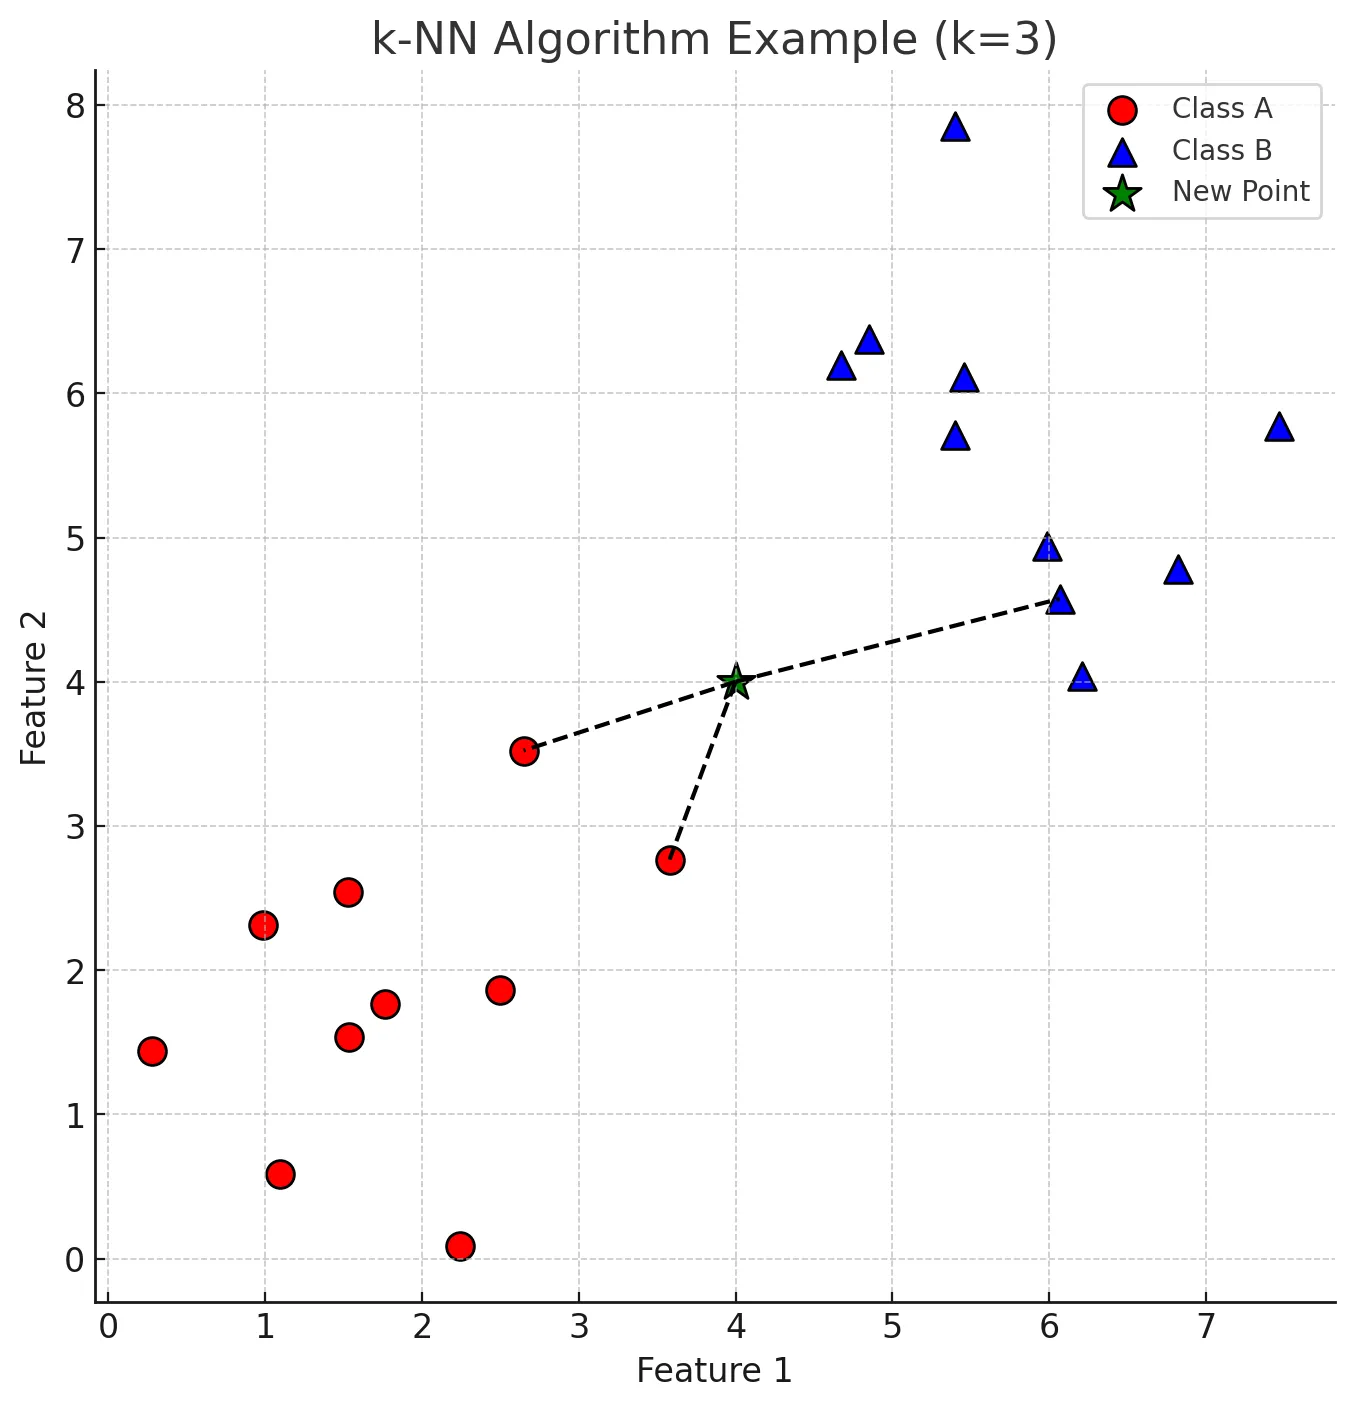

**k-NN 그래프 설명**:

- **빨간색 원**: 클래스 A에 속하는 데이터 포인트들
- **파란색 삼각형**: 클래스 B에 속하는 데이터 포인트들
- **초록색 별**: 분류되지 않은 새로운 데이터 포인트
- **점선**: 새로운 데이터 포인트와 가장 가까운 k개의 이웃을 연결하는 선 이 예제에서는 k=3으로 설정

**k-NN 알고리즘**:

1. 새로운 데이터 포인트(초록색 별)와 모든 기존 데이터 포인트(빨간색 원과 파란색 삼각형) 사이의 거리 계산
2. 가장 가까운 k=3개의 이웃을 선택합니다. 이 이웃들은 점선으로 연결
3. 선택된 이웃 중 다수결에 따라 새로운 데이터 포인트의 클래스를 결정  
이 예에서는 새로운 데이터 포인트가 어떤 클래스에 속할지 결정

### **k-NN 알고리즘 수식 표현**

1. **유클리드 거리 계산**: 두 점 $A(x_1, y_1)$와  $B(x_2, y_2)$ 사이의 유클리드 거리는 다음과 같이 계산:

$d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

더 일반적으로, 두 $n$-차원 벡터 $x = (x_1, x_2, \dots, x_n)$ 와  $y = (y_1, y_2, \dots, y_n)$ 사이의 유클리드 거리:

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

1. **k-NN 분류**:
    - 새로운 데이터 포인트 $x'$가 주어졌을 때, 그 점과 가장 가까운 $k$개의 이웃 찾음
    - 각 이웃의 클래스를 확인하고, 가장 많이 나타나는 클래스를 $x'$의 클래스로 할당
    
    $$
    y' = \arg\max_{c} \sum_{i=1}^{k} I(y_i = c)
    $$
    
    여기서 $I$는 지시 함수로, $y_i$가 클래스 $c$와 동일할 경우 1을, 그렇지 않으면 0을 반환
    
2. **k-NN 회귀**:
    - 새로운 데이터 포인트 $x'$의 예측 값은 가장 가까운 $k$개의 이웃의 출력 값의 평균으로 계산
    
    $$
    y' = \frac{1}{k} \sum_{i=1}^{k} y_i
    $$
    


### **k-NN 알고리즘의 주요 특징**

- **장점**:
    - 이해하고 구현하기 쉬움
    - 새로운 데이터에 대해 학습이 필요 없이 바로 예측 가능
- **단점**:
    - 데이터 포인트가 많아지면 계산량이 급격히 증가
    - 데이터의 차원이 높아지면(즉, 특징이 많아지면) 성능이 저하될 수 있음  
    이를 **차원의 저주**(Curse of Dimensionality)라고 함

### **k-NN의 활용 예**

- **이미지 분류**: 특정 이미지가 어떤 카테고리에 속하는지 분류할 때 사용
- **추천 시스템**: 사용자 간의 유사성을 측정하여 비슷한 선호도를 가진 사용자들에게 유사한 콘텐츠를 추천할 때 사용
- **의료 진단**: 특정 증상을 가진 환자가 어떤 질병에 걸렸는지 예측할 때 사용될 수 있음

다음의 코드는 한국 청소년들의 의류 구매패턴을 k-NN 알고리즘을 이용해 분석하고 학습한 뒤 추천하는 예시이다

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. 가상 한국 청소년 의류 구매 패턴 데이터 생성 및 추천 정보 포함
def generate_korean_teen_fashion_data_with_recommendations():
    # 데이터 생성
    data = {
        'Teenager': ['Teen1', 'Teen2', 'Teen3', 'Teen4', 'Teen5', 'Teen6', 'Teen7', 'Teen8', 'Teen9', 'Teen10'],
        'Sportswear': [5, 3, 2, 4, 5, 2, 3, 4, 5, 1],
        'Casual': [3, 4, 5, 3, 2, 4, 3, 4, 2, 5],
        'Luxury': [2, 5, 4, 2, 3, 5, 2, 1, 3, 4],
        'Streetwear': [4, 2, 5, 4, 3, 1, 4, 5, 2, 3],
        'Fashionable': [5, 4, 3, 5, 4, 3, 2, 5, 4, 3],
        'Average_Spending': [100000, 150000, 80000, 95000, 120000, 60000, 110000, 140000, 130000, 90000]  # 원 단위
    }
    df = pd.DataFrame(data)

    # 추천 정보 추가
    recommendations = {
        'Teen1': {'Brand': 'Nike', 'Category': 'Sportswear', 'Spending': 100000},
        'Teen2': {'Brand': 'Adidas', 'Category': 'Casual', 'Spending': 150000},
        'Teen3': {'Brand': 'Gucci', 'Category': 'Luxury', 'Spending': 80000},
        'Teen4': {'Brand': 'Supreme', 'Category': 'Streetwear', 'Spending': 95000},
        'Teen5': {'Brand': 'Zara', 'Category': 'Fashionable', 'Spending': 120000},
        'Teen6': {'Brand': 'Uniqlo', 'Category': 'Casual', 'Spending': 60000},
        'Teen7': {'Brand': 'Puma', 'Category': 'Sportswear', 'Spending': 110000},
        'Teen8': {'Brand': 'H&M', 'Category': 'Fashionable', 'Spending': 140000},
        'Teen9': {'Brand': 'Adidas', 'Category': 'Casual', 'Spending': 130000},
        'Teen10': {'Brand': 'Nike', 'Category': 'Sportswear', 'Spending': 90000}
    }

    return df, recommendations

# 2. 데이터 로드 및 분할
df, brand_recommendations = generate_korean_teen_fashion_data_with_recommendations()

X = df[['Sportswear', 'Casual', 'Luxury', 'Streetwear', 'Fashionable', 'Average_Spending']]
y = df['Teenager']

# 3. K-NN 모델 학습
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# 4. 새로운 청소년 구매 패턴 데이터
new_teen = pd.DataFrame({
    'Sportswear': [1],
    'Casual': [5],
    'Luxury': [2],
    'Streetwear': [5],
    'Fashionable': [3],
    'Average_Spending': [50000]  # 원 단위로 예상되는 지출 금액
})

# 5. 새로운 청소년의 구매 패턴에 따른 추천 패턴 예측
predicted_teen = knn.predict(new_teen)[0]
print(f"Predicted Teenager Similarity: {predicted_teen}")

# 6. 예측된 청소년 패턴에 따른 추천 브랜드, 카테고리 및 사용 금액
recommendation = brand_recommendations.get(predicted_teen, None)

# 올바른 형태의 데이터로 접근할 수 있도록 수정
if isinstance(recommendation, dict):
    print(f"Recommended Brand: {recommendation['Brand']}")
    print(f"Recommended Category: {recommendation['Category']}")
    print(f"Expected Spending: {recommendation['Spending']} 원")
else:
    print("No recommendation available.")

Predicted Teenager Similarity: Teen10
Recommended Brand: Nike
Recommended Category: Sportswear
Expected Spending: 90000 원


K-NN 알고리즘을 이용한 MBTI 분석

In [8]:
!pip install scikit-learn pandas numpy

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# MBTI 설명을 위한 함수 정의 (외부 모듈 대체)
def explain_mbti(mbti_type):
    explanations = {
        'INTJ': "전략적이고 독립적인 사색가로, 목표 지향적이고 계획을 잘 세움.",
        'ENFP': "창의적이고 에너지가 넘치며, 새로운 아이디어를 좋아하는 열정적인 사람.",
        'ISTJ': "실용적이고 조직적인 성격으로, 규칙을 잘 따르고 신뢰성이 높음.",
        'ESFP': "사교적이고 즉흥적이며, 사람들과 함께하는 것을 즐기는 유형.",
        'ENTP': "호기심이 많고 논리적이며, 다양한 아이디어를 탐구하는 토론자.",
        'INFJ': "통찰력이 뛰어나고 공감 능력이 높은 이상주의적 리더.",
        'ESTJ': "조직적이고 결단력 있는 리더 유형으로, 강한 실행력을 가짐.",
        'INFP': "창의적이고 감성적이며, 깊은 내면을 중요하게 여기는 이상주의자.",
        'ISFJ': "책임감이 강하고 배려심이 깊으며, 조화를 중요시하는 성격.",
        'ENTJ': "대담하고 강한 리더십을 가진 사람으로, 목표 지향적인 전략가.",
        'ENFJ': "타인의 성장을 돕는 데 관심이 많으며, 뛰어난 소통 능력을 가진 사람.",
        'ISTP': "실용적이고 논리적인 문제 해결사로, 독립적인 사고를 가진 유형."
    }
    return explanations.get(mbti_type, "설명이 없습니다.")

# 1. 가상의 MBTI 데이터 생성
data = {
    'Extraversion': [1, 4, 1, 5, 4, 2, 5, 1, 1, 4, 5, 1], # 외향성
    'Intuition': [4, 5, 1, 2, 5, 4, 1, 5, 2, 4, 5, 1],    # 직관
    'Thinking': [5, 1, 4, 2, 4, 2, 5, 2, 3, 5, 1, 4],     # 사고
    'Judging': [4, 1, 5, 1, 2, 4, 5, 2, 5, 4, 4, 1],      # 판단
    'MBTI': ['INTJ', 'ENFP', 'ISTJ', 'ESFP', 'ENTP', 'INFJ', 'ESTJ', 'INFP', 'ISFJ', 'ENTJ', 'ENFJ', 'ISTP']
}

df = pd.DataFrame(data)

# 2. 특징과 레이블 나누기
X = df[['Extraversion', 'Intuition', 'Thinking', 'Judging']]
y = df['MBTI']

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. k-NN 모델 학습
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

# 5. 예측 수행
y_pred = knn.predict(X_test)

# 6. 모델 성능 평가
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# 7. 새로운 사용자 데이터 예측
new_user = pd.DataFrame({
    'Extraversion': [1],
    'Intuition': [1],
    'Thinking': [2],
    'Judging': [1]
})

predicted_mbti = knn.predict(new_user)[0]
print(f"Predicted MBTI for the new user: {predicted_mbti}")

# 8. 예측된 MBTI 유형에 대한 설명 출력
explanation = explain_mbti(predicted_mbti)
print(f"Explanation: {explanation}")


Accuracy: 0.00

Classification Report:
              precision    recall  f1-score   support

        ENFJ       1.00      0.00      0.00       1.0
        ENFP       0.00      1.00      0.00       0.0
        ENTJ       1.00      0.00      0.00       1.0
        ENTP       0.00      1.00      0.00       0.0
        INFJ       0.00      1.00      0.00       0.0
        INTJ       1.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.50      0.50      0.00       3.0
weighted avg       1.00      0.00      0.00       3.0

Predicted MBTI for the new user: INFP
Explanation: 창의적이고 감성적이며, 깊은 내면을 중요하게 여기는 이상주의자.


다음의 테이블은 의류 구매 데이터셋이다. 위 K-NN 예제를 참고하여 데이터셋에서 소비자 구매 패턴을 파악하고 신규 고객에 대한 브랜드 추천시스템을 구축하라(시스템 구성은 자유롭게 할수 있습니다)

| Email | Age | Gender | ClothingCategory | Brand | PurchaseAmount (원) | PurchaseLocation |
| --- | --- | --- | --- | --- | --- | --- |
| yuna.kim23@gmail.com | 23 | Female | Sportswear | Nike | 120,000 | 강남점 (Seoul) |
| minho_lee45@outlook.com | 45 | Male | Casual | Adidas | 80,000 | 수원역점 (Suwon) |
| jisoo-park@naver.com | 34 | Female | Luxury | Gucci | 350,000 | 압구정점 (Seoul) |
| hyunwoo.choi@gmail.com | 29 | Male | Streetwear | Supreme | 200,000 | 부산 센텀시티점 (Busan) |
| seo_young_kim@kakao.com | 41 | Female | Casual | Zara | 75,000 | 대구 동성로점 (Daegu) |
| lee.donghae@daum.net | 22 | Male | Luxury | Louis Vuitton | 400,000 | 롯데백화점 명동점 (Seoul) |
| jiwoo.jung_1985@naver.com | 36 | Female | Sportswear | Puma | 130,000 | 광주 충장로점 (Gwangju) |
| hyesoo-p@naver.com | 30 | Male | Fashionable | H&M | 60,000 | 신세계백화점 강남점 (Seoul) |
| [choi.soobin88@yahoo.com](mailto:choi.soobin88@yahoo.com) | 28 | Female | Streetwear | Supreme | 180,000 | 롯데백화점 부산본점 (Busan) |
| minji.kim39@gmail.com | 39 | Male | Casual | Adidas | 90,000 | 대전 은행동점 (Daejeon) |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 생성
data = {
    'Age': [23, 45, 34, 29, 41, 22, 36, 30, 28, 39],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'ClothingCategory': ['Sportswear', 'Casual', 'Luxury', 'Streetwear', 'Casual', 'Luxury', 'Sportswear', 'Fashionable', 'Streetwear', 'Casual'],
    'Brand': ['Nike', 'Adidas', 'Gucci', 'Supreme', 'Zara', 'Louis Vuitton', 'Puma', 'H&M', 'Supreme', 'Adidas'],
    'PurchaseAmount': [120000, 80000, 350000, 200000, 75000, 400000, 130000, 60000, 180000, 90000],
    'PurchaseLocation': ['Seoul', 'Suwon', 'Seoul', 'Busan', 'Daegu', 'Seoul', 'Gwangju', 'Seoul', 'Busan', 'Daejeon']
}

df = pd.DataFrame(data)

# 2. 데이터 전처리 (Label Encoding)
label_encoders = {}
for col in ['Gender', 'ClothingCategory', 'PurchaseLocation']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 타겟 변수 (Brand) 인코딩
y_le = LabelEncoder()
df['Brand'] = y_le.fit_transform(df['Brand'])
y = df['Brand']

X = df[['Age', 'Gender', 'ClothingCategory', 'PurchaseAmount', 'PurchaseLocation']]

# 3. K-NN 모델 학습
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 4. 신규 고객 추천 시스템
def recommend_brand(new_customer):
    """
    새로운 고객 정보를 입력하면 가장 유사한 기존 고객을 찾고 브랜드를 추천하는 함수
    """
    # 데이터프레임 변환
    new_user_df = pd.DataFrame([new_customer])

    # Label Encoding 적용
    for col in ['Gender', 'ClothingCategory', 'PurchaseLocation']:
        new_user_df[col] = label_encoders[col].transform([new_user_df[col][0]])

    # 예측 수행
    predicted_brand = knn.predict(new_user_df)[0]
    predicted_brand_name = y_le.inverse_transform([predicted_brand])[0]

    return predicted_brand_name

# 5. 테스트 - 신규 고객 예측
new_customer = {
    'Age': 27,
    'Gender': 'Female',
    'ClothingCategory': 'Luxury',
    'PurchaseAmount': 250000,
    'PurchaseLocation': 'Seoul'
}

recommended_brand = recommend_brand(new_customer)
print(f"Recommended Brand for New Customer: {recommended_brand}")

Recommended Brand for New Customer: Gucci


### sales.csv

위의 내용에 대해 주어진 데이터셋을 이용해 신규고객에 대한 의류상품 추천이 가능하도록 웹사이트를 구축하시오.

  1. 데이터셋은 pandas data frame으로 처리  
  2. 사용자의 구매패턴을 생성한 후 K-NN 알고리즘을 이용해 추천 내용을 페이지로 이동  
  3. new_customer의 내용은 웹에서 입력 받아 처리할 수 있도록 할 것  
  4. Flask를 활용해 Web service 를 구축하시오.

In [22]:
display(df)

,Email,Age,Gender,ClothingCategory,Brand,PurchaseAmount (원),PurchaseLocation
0,minho_lee45@outlook.com,26,Female,Sportswear,Louis Vuitton,255000,광주 충장로점 (Gwangju)
1,minji.kim39@gmail.com,45,Male,Casual,Louis Vuitton,270000,광주 충장로점 (Gwangju)
2,hyesoo-p@naver.com,45,Female,Fashionable,H&M,365000,대전 은행동점 (Daejeon)
3,minho_lee45@outlook.com,29,Female,Casual,Gucci,65000,수원역점 (Suwon)
4,hyesoo-p@naver.com,22,Female,Sportswear,H&M,380000,롯데백화점 부산본점 (Busan)
...,...,...,...,...,...,...,...
2295,hyesoo-p@naver.com,53,Female,Streetwear,Adidas,405000,대구 동성로점 (Daegu)
2296,choi.soobin88@yahoo.com,34,Female,Fashionable,Puma,90000,부산 센텀시티점 (Busan)
2297,yuna.kim23@gmail.com,40,Female,Streetwear,Louis Vuitton,230000,부산 센텀시티점 (Busan)
2298,jisoo-park@naver.com,33,Male,Fashionable,Adidas,140000,롯데백화점 명동점 (Seoul)


**app.py**

In [ ]:
from flask import Flask, request, render_template
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

app = Flask(__name__)

# 데이터셋 로드
file_path = 'sales.csv'
df = pd.read_csv(file_path)

# 'PurchaseAmount (원)' 컬럼명을 'PurchaseAmount'로 변경
df.rename(columns={'PurchaseAmount (원)': 'PurchaseAmount'}, inplace=True)

# 필요한 데이터 전처리
X = df[['Age', 'Gender', 'ClothingCategory', 'Brand', 'PurchaseAmount']]  # 필요한 특성만 선택
y = df['Email']  # 타겟 변수 (Email)

# 범주형 데이터를 수치형으로 변환
X = pd.get_dummies(X)

# 데이터셋을 학습과 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# K-NN 모델 학습
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 드롭다운 옵션을 위한 고유 값 추출
gender_options = df['Gender'].unique().tolist()
clothing_category_options = df['ClothingCategory'].unique().tolist()
brand_options = df['Brand'].unique().tolist()

@app.route('/')
def index():
    return render_template('index.html',
                           gender_options=gender_options,
                           clothing_category_options=clothing_category_options,
                           brand_options=brand_options)

@app.route('/predict', methods=['POST'])
def predict_customer():
    if request.method == 'POST':
        # 폼에서 입력된 데이터를 가져옴
        age = int(request.form['age'])
        gender = request.form['gender']
        clothing_category = request.form['clothing_category']
        brand = request.form['brand']
        purchase_amount = int(request.form['purchase_amount'])

        # 새로운 고객 데이터 프레임 생성
        new_customer = pd.DataFrame({
            'Age': [age],
            'Gender': [gender],
            'ClothingCategory': [clothing_category],
            'Brand': [brand],
            'PurchaseAmount': [purchase_amount]
        })

        # 새로운 고객 데이터에 대해 One-Hot Encoding 적용
        new_customer = pd.get_dummies(new_customer)
        new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

        # 가장 유사한 고객의 Email 예측
        predicted_customer = knn.predict(new_customer)[0]

        # 유사한 고객의 구매 패턴 확인 및 추천
        similar_customers = df[df['Email'] == predicted_customer]
        if not similar_customers.empty:
            input_amount = new_customer['PurchaseAmount'].values[0]

            # 입력 금액과 가장 유사한 상품을 찾기 위해 오차를 계산
            df['AmountDifference'] = abs(df['PurchaseAmount'] - input_amount)

            # 오차가 작은 상품을 추천 (여기서는 상위 5개의 유사한 상품을 추천)
            recommended_products = df.nsmallest(5, 'AmountDifference')

            return render_template('result.html',
                                   predicted_email=predicted_customer,
                                   recommendations=recommended_products[['Brand', 'ClothingCategory', 'PurchaseAmount', 'PurchaseLocation']].to_html(index=False))
        else:
            return render_template('result.html', predicted_email=predicted_customer, recommendations=None)

    return render_template('index.html')

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001, debug=True)


**templates/index.html**

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>고객 구매 예측</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f4f4;
            color: #333;
            margin: 0;
            padding: 20px;
        }
        .container {
            max-width: 600px;
            margin: 0 auto;
            background-color: #fff;
            padding: 20px;
            border-radius: 10px;
            box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
        }
        h1 {
            text-align: center;
            color: #444;
        }
        label {
            font-weight: bold;
            margin-top: 10px;
            display: block;
        }
        input[type="number"], select {
            width: 100%;
            padding: 10px;
            margin-top: 5px;
            margin-bottom: 20px;
            border: 1px solid #ccc;
            border-radius: 5px;
            box-sizing: border-box;
        }
        input[type="submit"] {
            width: 100%;
            padding: 10px;
            background-color: #007BFF;
            color: #fff;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            font-size: 16px;
        }
        input[type="submit"]:hover {
            background-color: #0056b3;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>고객 구매 예측</h1>
        <form action="/predict" method="post">
            <label for="age">나이:</label>
            <input type="number" id="age" name="age" required>

            <label for="gender">성별:</label>
            <select id="gender" name="gender" required>
                {% for option in gender_options %}
                <option value="{{ option }}">{{ option }}</option>
                {% endfor %}
            </select>

            <label for="clothing_category">의류 카테고리:</label>
            <select id="clothing_category" name="clothing_category" required>
                {% for option in clothing_category_options %}
                <option value="{{ option }}">{{ option }}</option>
                {% endfor %}
            </select>

            <label for="brand">브랜드:</label>
            <select id="brand" name="brand" required>
                {% for option in brand_options %}
                <option value="{{ option }}">{{ option }}</option>
                {% endfor %}
            </select>

            <label for="purchase_amount">구매 금액 (원):</label>
            <input type="number" id="purchase_amount" name="purchase_amount" required>

            <input type="submit" value="예측하기">
        </form>
    </div>
</body>
</html>

**templates/result.html**

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>예측 결과</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f4f4;
            color: #333;
            margin: 0;
            padding: 20px;
        }
        .container {
            max-width: 600px;
            margin: 0 auto;
            background-color: #fff;
            padding: 20px;
            border-radius: 10px;
            box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
        }
        h1 {
            text-align: center;
            color: #444;
        }
        h2 {
            color: #444;
            margin-top: 20px;
        }
        p {
            font-size: 16px;
            line-height: 1.5;
        }
        .recommendations {
            margin-top: 20px;
        }
        table {
            width: 100%;
            border-collapse: collapse;
            margin-top: 20px;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
        }
        a {
            display: block;
            text-align: center;
            margin-top: 20px;
            text-decoration: none;
            color: #007BFF;
            font-weight: bold;
        }
        a:hover {
            color: #0056b3;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>예측 결과</h1>
        {% if recommendations %}
            <h2>추천 상품:</h2>
            <div class="recommendations">
                {{ recommendations | safe }}
            </div>
            <p>고객님의 구매 금액을 바탕으로 유사한 상품을 추천해 드립니다!</p>
        {% else %}
            <p>안타깝게도 추천할 유사한 상품을 찾지 못했습니다.</p>
        {% endif %}
        <a href="/">다른 고객 예측하기</a>
    </div>
</body>
</html>

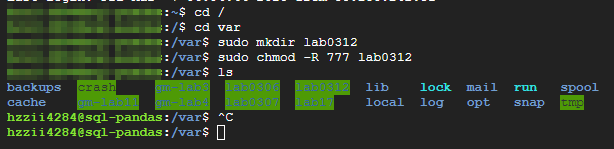

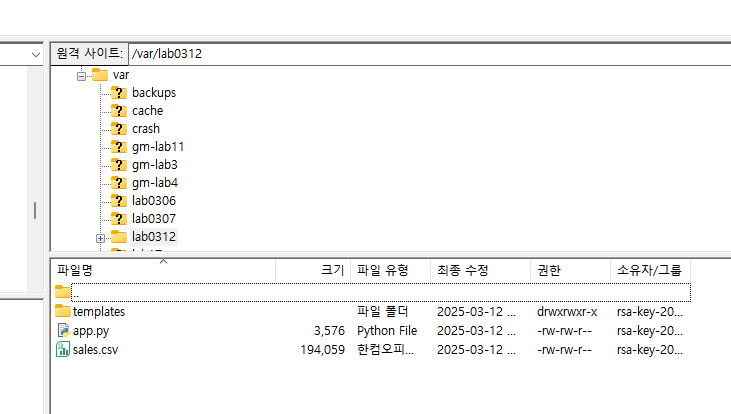

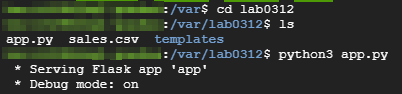

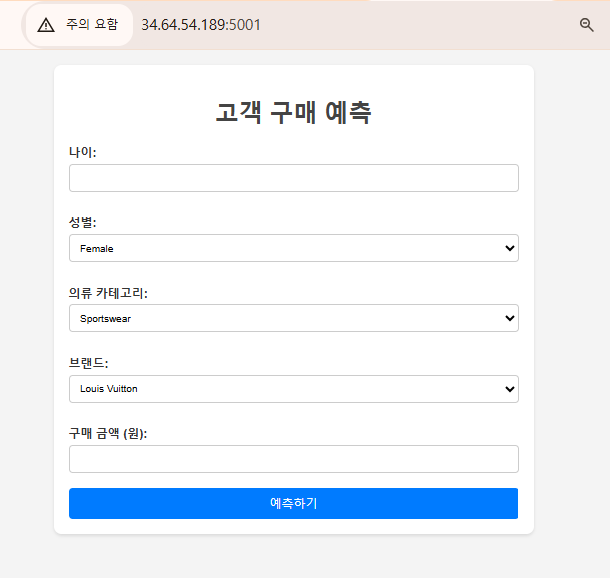

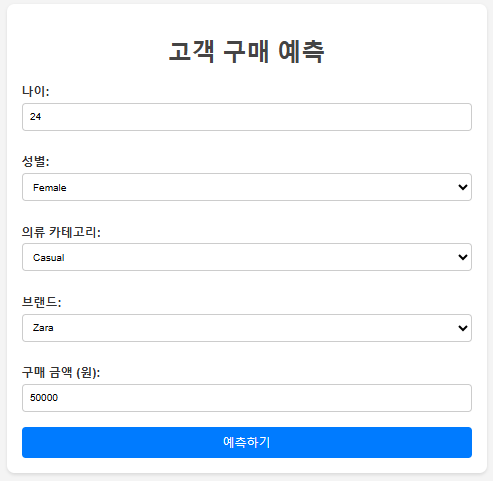 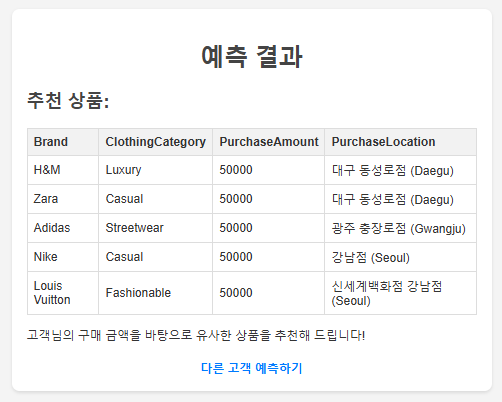



---

##**서포트 벡터 머신(SVM)**

서포트 벡터 머신(SVM, Support Vector Machines)은 지도학습의 한 방법으로, 주로 분류(Classification)와 회귀(Regression) 문제에 사용됨  
SVM은 주어진 데이터를 기반으로 최적의 초평면(Hyperplane)을 찾아, 새로운 데이터 포인트를 분류하거나 예측하는 역할을 함

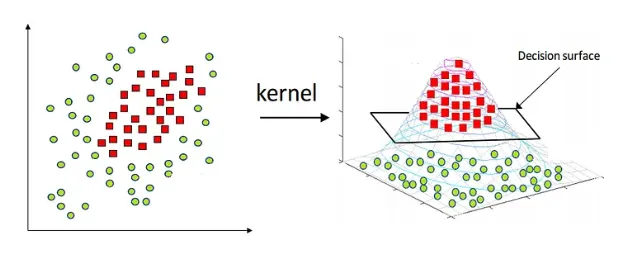

### **활용 분야**

- **이미지 분류(Image Classification)**: 손글씨 숫자 인식에서 SVM은 각 숫자를 분류하는 데 사용될 수 있음
- **텍스트 분류(Text Classification)**: 스팸 필터링과 같은 이메일 분류 문제에서 SVM은 효과적인 도구
- **의료 진단(Medical Diagnosis)**: SVM은 다양한 의료 데이터 분석에서 질병 진단을 위한 분류 도구로 활용

### **지도학습에서의 사용**

SVM은 지도학습(Supervised Learning)의 대표적인 분류 알고리즘으로, 라벨이 포함된 데이터를 학습하여 새로운 데이터의 라벨을 예측  
이때, 각 데이터 포인트는 벡터 형태로 표현되며, SVM은 이 벡터들을 분류할 수 있는 초평면을 학습  
지도학습에서 SVM은 특히 이진 분류 문제에서 높은 성능을 보임

### **SVM의 개념**

SVM은 주어진 데이터에서 두 클래스를 구분하는 최적의 초평면을 찾습니다. 이때, 각 클래스의 가장 가까운 데이터 포인트(즉, 서포트 벡터)와 초평면 사이의 거리를 최대화하는 것을 목표로 합니다.

- **초평면(Hyperplane)**: 데이터를 분류하는 데 사용되는 경계
- **마진(Margin)**: 각 클래스의 서포트 벡터와 초평면 사이의 거리  
SVM은 이 마진을 최대화하는 초평면을 찾음
- **서포트 벡터(Support Vectors)**: 각 클래스에서 초평면에 가장 가까운 데이터 포인트들  
이 서포트 벡터는 최적의 초평면을 정의하는 데 중요한 역할을 함

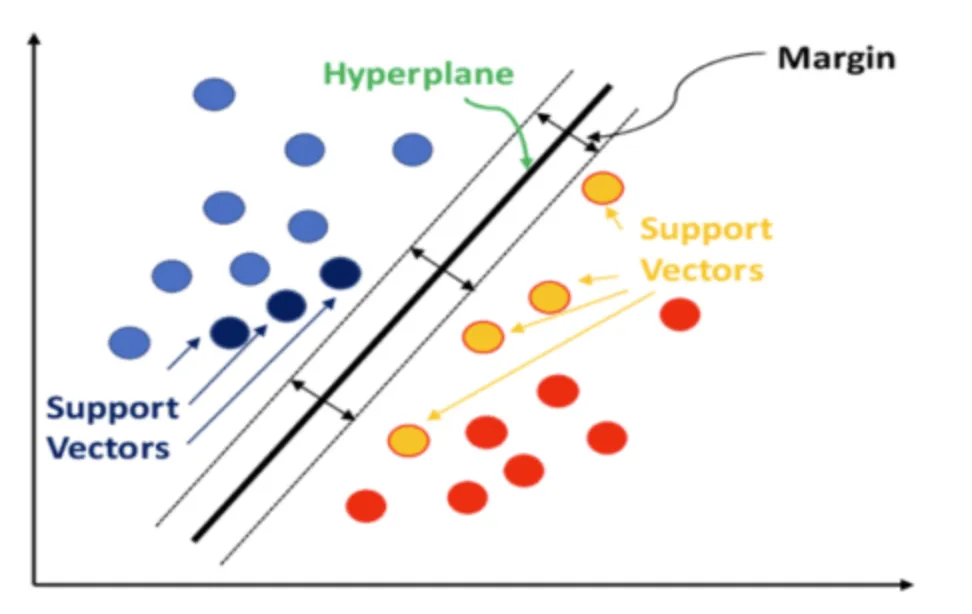

### SVM의 수식 표현

SVM에서 최적의 초평면을 찾기 위해 다음과 같은 수식을 사용합니다:

$$
\text{H(x)} = \mathbf{w} \cdot \mathbf{x} + b = 0
$$

여기서:

- $\mathbf{w}$는 초평면의 기울기를 나타내는 벡터입니다.

<aside>
🧑🏻‍🎓

$\|\mathbf{w}\|$ 는 벡터 $\mathbf{w}$의 norm 또는 **크기**를 나타냅니다. 이것은 벡터의 길이를 의미하며, 주로 **유클리드 norm**(Euclidean norm) 또는 **L2 노름**을 의미합니다.

벡터 $\mathbf{w} = [w_1, w_2, \dots, w_n]$에 대해, $\|\mathbf{w}\|$는 다음과 같이 계산됩니다:

$$
\|\mathbf{w}\| = \sqrt{w_1^2 + w_2^2 + \dots + w_n^2}
$$

이 식은 벡터 $\mathbf{w}$의 각 성분을 제곱한 후, 이를 모두 더한 값을 제곱근한 결과를 나타냅니다. **유클리드 노름**은 벡터 공간에서 벡터의 실제 길이를 측정하는 방법으로, SVM에서 마진을 계산할 때 사용됩니다.

</aside>

- $\mathbf{x}$는 입력 데이터 포인트 벡터입니다.
- $b$는 초평면의 절편을 나타냅니다.

SVM의 목적은 서포트 벡터와 초평면 사이의 거리를 최대화하는 $\mathbf{w}$와 $b$를 찾는 것입니다. 이때 마진(Margin)은 다음과 같이 정의됩니다:

$$
\text{Margin} = \frac{2}{\|\mathbf{w}\|}
$$

마진을 최대화하는 것은 $\|\mathbf{w}\|$를 최소화하는 것과 같습니다. 이 문제는 다음과 같은 최적화 문제로 변환됩니다:

$$
\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2
$$

이 조건은 모든 $i$에 대해 다음과 같이 주어집니다:

$$
y_i (\mathbf{w} \cdot \mathbf{x_i} + b) \geq 1
$$

여기서 $y_i$는 각 데이터 포인트 $\mathbf{x_i}$의 실제 라벨(1 또는 -1)을 나타냅니다.

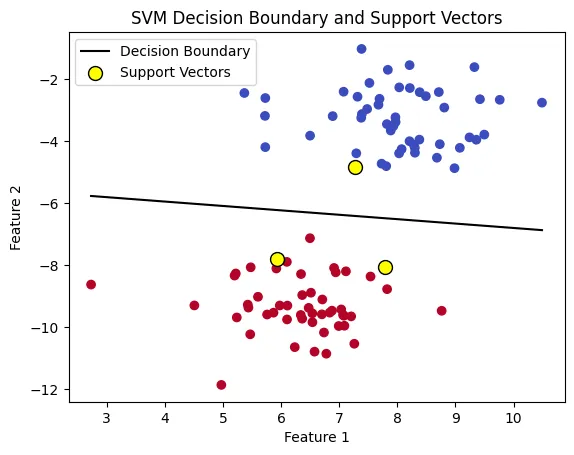

- **Decision Boundary**: 검정색 선은 SVM이 학습한 초평면(결정 경계)을 나타냄  
이 선은 두 클래스 사이를 최대한 분리하는 역할을 함
- **Support Vectors**: 노란색 점들은 서포트 벡터를 나타냄  
이 점들은 결정 경계의 위치를 결정하는 데 중요한 역할을 함
- **Classes**: 데이터 포인트는 두 개의 클래스(파란색과 빨간색)로 나뉨  
SVM은 이 클래스들을 최대한 분리하는 초평면을 찾음



---

예제 1 : SVM을 이용해 개와 고양이 사진을 학습해 분류하는 예시  

[data.zip](https://prod-files-secure.s3.us-west-2.amazonaws.com/2caac87b-5e53-4ec3-8c82-884c7e4c6365/cb7665b2-b746-4dc1-b39e-eb89370a9abd/data.zip)

위 예제는 이미지 데이터를 활용하여 개와 고양이를 분류하는 SVM(Support Vector Machine) 모델을 구축하는 예제입니다. 또한, ROC(Receiver Operating Characteristic) 곡선을 그려서 모델의 성능을 평가합니다. 아래에서 코드의 각 부분을 자세하게 설명하겠습니다.

In [40]:
import cv2
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from skimage.feature import hog
import matplotlib.pyplot as plt
import os

# 1. HOG 특징 추출 함수
def extract_hog_features(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # 이미지를 흑백으로 변환
    hog_features, hog_image = hog(gray_image, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True)
    return hog_features

# 2. 이미지 로드 및 전처리
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = 0 if 'cat' in filename else 1  # 파일명에 'cat'이 포함된 이미지를 고양이로, 그렇지 않으면 개로 라벨링
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (64, 64))  # 이미지 크기를 통일
            images.append(extract_hog_features(img))
            labels.append(label)
    return np.array(images), np.array(labels)

# 3. 데이터 로드
folder_path = '/content/drive/MyDrive/ColabNotebooks/GM/data'  # 구글 드라이브에 있는 데이터셋 폴더 경로
X, y = load_images_from_folder(folder_path)

# 4. 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# 5. SVM 모델 학습
model = svm.SVC(kernel='linear')
model.fit(X_train, y_train)

# 6. 예측 및 정확도 평가
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')

# 7. 테스트 이미지 예측 및 시각화
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (64, 64))
    features = extract_hog_features(img_resized)
    features = features.reshape(1, -1)

    prediction = model.predict(features)

    if prediction == 0:
        print("It's a cat!")
    else:
        print("It's a dog!")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Prediction: Cat" if prediction == 0 else "Prediction: Dog")
    plt.show()

# 예측 예시
predict_image('/content/drive/MyDrive/ColabNotebooks/GM/data/dog.jpeg')

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. 예측 확률 계산 (SVM에서 결정 함수 사용)
y_scores = model.decision_function(X_test)

# 2. ROC 곡선 데이터 계산
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# 3. AUC 값 계산
auc_score = roc_auc_score(y_test, y_scores)

# 4. ROC 곡선 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 대각선 선: 무작위 예측
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

ValueError: With n_samples=0, test_size=None and train_size=0.8, the resulting train set will be empty. Adjust any of the aforementioned parameters.

### 1. 라이브러리 임포트

```python
import cv2
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from skimage.feature import hog
import matplotlib.pyplot as plt
import os
```

이 부분에서는 이미지 처리, 머신러닝 모델, 성능 평가, 시각화에 필요한 라이브러리를 가져옵니다. 주요 라이브러리는 다음과 같습니다:

- `cv2`: OpenCV를 사용하여 이미지를 로드하고 처리합니다.
- `numpy`: 배열 및 수치 계산을 위한 라이브러리입니다.
- `svm`: Scikit-learn에서 제공하는 SVM 모델입니다.
- `accuracy_score`: 모델의 예측 정확도를 계산합니다.
- `train_test_split`: 데이터를 학습용과 테스트용으로 분할합니다.
- `hog`: HOG(Histogram of Oriented Gradients) 특징을 추출하는 데 사용됩니다.
- `matplotlib`: 그래프 시각화에 사용됩니다.
- `os`: 파일 및 디렉터리 작업을 수행합니다.

### 2. HOG 특징 추출 함수

```python
def extract_hog_features(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # 이미지를 흑백으로 변환
    hog_features, hog_image = hog(gray_image, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True)
    return hog_features
```

- 이 함수는 이미지를 입력으로 받아 HOG 특징을 추출합니다.
- 먼저 `cv2.cvtColor`를 사용해 이미지를 흑백으로 변환합니다. SVM 모델은 흑백 이미지에서 특징을 추출하는 것이 일반적입니다.
- `hog` 함수를 사용하여 HOG 특징과 HOG 이미지를 추출합니다. `pixels_per_cell`과 `cells_per_block`는 HOG의 구성 요소로, 각각 픽셀 셀 크기와 블록 크기를 정의합니다.
- 반환되는 값은 HOG 특징 벡터입니다.

### 3. 이미지 로드 및 전처리

```python
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = 0 if 'cat' in filename else 1  # 파일명에 'cat'이 포함된 이미지를 고양이로, 그렇지 않으면 개로 라벨링
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (64, 64))  # 이미지 크기를 통일
            images.append(extract_hog_features(img))
            labels.append(label)
    return np.array(images), np.array(labels)
```

- 이 함수는 지정된 폴더에서 이미지를 로드하고 전처리합니다.
- 파일 이름에 'cat'이 포함되면 `label`을 0으로, 그렇지 않으면 1로 설정하여 고양이와 개를 라벨링합니다.
- `cv2.imread`로 이미지를 로드하고, `cv2.resize`로 이미지 크기를 64x64 픽셀로 통일합니다.
- `extract_hog_features` 함수를 사용하여 각 이미지의 HOG 특징을 추출하고, 이 특징을 `images` 리스트에 추가합니다. 라벨은 `labels` 리스트에 추가합니다.
- 이 함수는 `images`와 `labels`를 넘파이 배열로 반환합니다.

### 4. 데이터 로드

```python
folder_path = '/content/data'  # 구글 드라이브에 있는 데이터셋 폴더 경로
X, y = load_images_from_folder(folder_path)
```

- `folder_path`는 이미지 데이터셋이 있는 폴더의 경로입니다.
- `load_images_from_folder` 함수를 호출하여 폴더에서 이미지를 로드하고, 각 이미지의 HOG 특징과 라벨을 `X`와 `y`에 저장합니다.

### 5. 데이터셋 분할

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31)
```

- `train_test_split` 함수를 사용하여 데이터를 학습용과 테스트용으로 분할합니다. 전체 데이터의 80%는 학습에, 20%는 테스트에 사용됩니다.
- `random_state=42`는 분할을 재현 가능하게 하기 위한 설정입니다.

### 6. SVM 모델 학습

```python
model = svm.SVC(kernel='linear')
model.fit(X_train, y_train)
```

- SVM 모델을 생성하고 `kernel='linear'`로 선형 커널을 설정합니다. SVM은 주로 선형, 비선형(예: RBF) 커널을 사용합니다.
- `fit` 메서드를 사용하여 학습 데이터를 바탕으로 모델을 학습시킵니다.

### 7. 예측 및 정확도 평가

```python
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
```

- 테스트 데이터(`X_test`)를 사용하여 모델이 예측을 수행합니다.
- `accuracy_score` 함수를 사용하여 예측 결과(`y_pred`)와 실제 라벨(`y_test`) 간의 정확도를 계산하고 출력합니다.

### 8. 테스트 이미지 예측 및 시각화

```python
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (64, 64))
    features = extract_hog_features(img_resized)
    features = features.reshape(1, -1)

    prediction = model.predict(features)

    if prediction == 0:
        print("It's a cat!")
    else:
        print("It's a dog!")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Prediction: Cat" if prediction == 0 else "Prediction: Dog")
    plt.show()
```

- 주어진 이미지 파일(`img_path`)에 대해 예측을 수행하는 함수입니다.
- 이미지를 로드하고 크기를 조정한 후, HOG 특징을 추출하여 1차원 배열로 변환합니다.
- `model.predict`로 예측을 수행합니다. 예측 결과에 따라 'cat' 또는 'dog'로 출력하고, 이미지를 시각화하여 예측 결과를 보여줍니다.

### 9. 예측 예시

```python
predict_image('/content/data/dog.jpeg')
```

- 이 줄은 `predict_image` 함수를 호출하여 특정 이미지(`dog.jpeg`)에 대한 예측을 수행하고 결과를 출력합니다.

### 10. ROC 곡선 그리기

```python
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. 예측 확률 계산 (SVM에서 결정 함수 사용)
y_scores = model.decision_function(X_test)

# 2. ROC 곡선 데이터 계산
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# 3. AUC 값 계산
auc_score = roc_auc_score(y_test, y_scores)

# 4. ROC 곡선 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 대각선 선: 무작위 예측
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
```

- 이 부분은 모델의 성능을 평가하기 위해 ROC 곡선을 그립니다.
- `decision_function` 메서드를 사용하여 SVM 모델의 결정 함수를 계산하고, 이를 통해 각 샘플이 속할 확률 점수를 얻습니다.
- `roc_curve`로 FPR(위양성률)과 TPR(진양성률)을 계산합니다.
- `roc_auc_score`로 AUC(Area Under the Curve) 값을 계산하여 ROC 곡선 아래의 면적을 얻습니다. AUC는 모델의 성능을 평가하는 지표로, 1에 가까울수록 좋은 성능을 나타냅니다.
- 마지막으로, `plt.plot`으로 ROC 곡선을 그립니다. ROC 곡선은 TPR 대 FPR의 그래프이며, 모델의 분류 성능을 시각화하는 데 사용됩니다.

이 코드는 SVM 모델을 사용하여 개와 고양이 이미지를 분류하고, 모델의 성능을 평가하는 방법을 보여줍니다. ROC 곡선과 AUC 값을 통해 모델의 예측 능력을 시각적으로 평가할 수 있습니다.

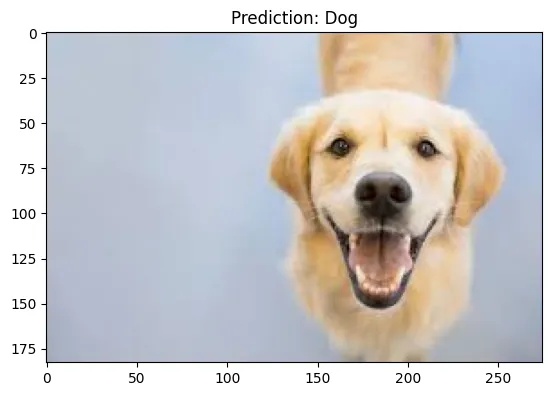  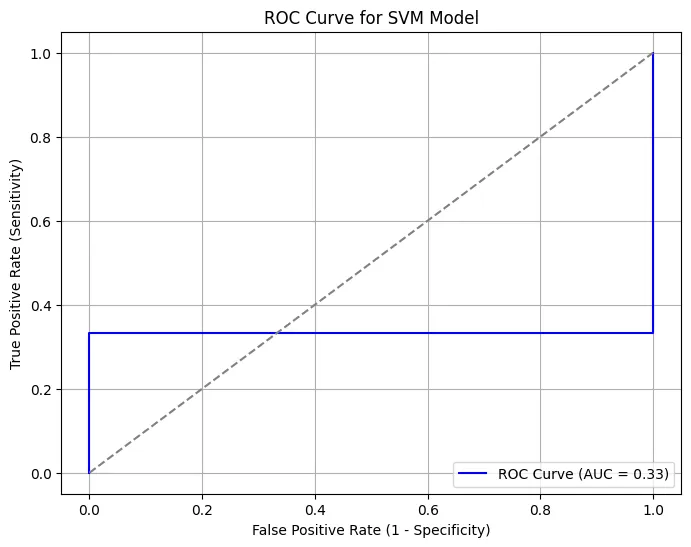

---

##**1. 비즈니스 시나리오**

#### **광고 캠페인 전환율 예측**

A사의 마케팅팀은 신규 온라인 광고 캠페인을 실행하고 있으며, 특정 고객이 광고를 본 후 실제 구매(전환)를 할 가능성이 높은지를 예측하고 싶다. 이를 통해 광고 예산을 최적화하고, 전환 가능성이 높은 고객에게 더 많은 마케팅 자원을 집중할 수 있다.

**목표**

- 고객의 인구통계 및 행동 데이터를 기반으로 전환(구매) 여부를 예측
- 로지스틱 회귀를 활용하여 고객이 전환할 확률을 계산
- 예측 결과를 기반으로 맞춤형 마케팅 전략 수립


### **2. 데이터 설명**

**사용할 데이터 예시**

- **고객 특성 데이터**
    - `age` (나이)
    - `income` (소득 수준)
    - `browsing_time` (웹사이트 체류 시간)
    - `num_clicks` (클릭 횟수)
    - `ad_exposure` (광고 노출 횟수)
    - `converted` (전환 여부: 1(구매), 0(비구매))

### **3. 코드 작성 (로지스틱 회귀 적용)**

Python을 활용하여 로지스틱 회귀 모델을 구축하고 평가하는 코드를 작성한다.

#### **필요 라이브러리 설치 및 데이터 준비**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# 가상의 고객 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'income': [3000, 6000, 3200, 5000, 7200, 6500, 4000, 5800, 7000, 3100,
               4800, 5500, 3900, 6200, 7500, 6700, 3500, 5600, 7100, 4200],
    'browsing_time': [5, 15, 7, 10, 20, 13, 8, 12, 18, 6, 9, 11, 8, 14, 21, 17, 7, 11, 19, 10],
    'num_clicks': [1, 5, 2, 3, 6, 4, 2, 3, 5, 1, 3, 4, 2, 4, 6, 5, 2, 3, 5, 2],
    'ad_exposure': [2, 6, 3, 5, 8, 7, 4, 6, 8, 3, 5, 6, 4, 7, 9, 7, 4, 6, 8, 5],
    'converted': [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

# 데이터 분할 (독립변수 X, 종속변수 y)
X = df[['age', 'income', 'browsing_time', 'num_clicks', 'ad_exposure']]
y = df['converted']

# 훈련 데이터와 테스트 데이터로 분할 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화 (로지스틱 회귀는 입력 스케일에 민감)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


####**로지스틱 회귀 모델 훈련 및 평가**

In [24]:
# 로지스틱 회귀 모델 생성
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# 결과 출력
print(f"모델 정확도: {accuracy:.2f}")
print(f"AUC 점수: {auc_score:.2f}")
print("혼동 행렬:")
print(conf_matrix)
print("분류 보고서:")
print(report)


모델 정확도: 1.00
AUC 점수: 1.00
혼동 행렬:
[[1 0]
 [0 3]]
분류 보고서:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



#### **ROC 커브 시각화**

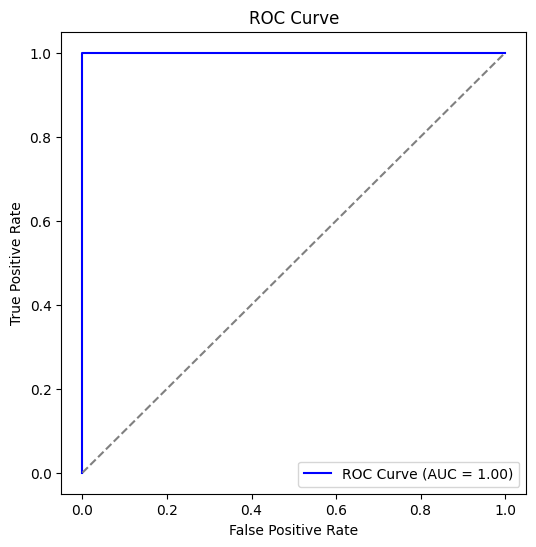

In [25]:
from sklearn.metrics import roc_curve

# ROC 곡선 계산
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# 그래프 그리기
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(auc_score))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### **결과 해석**

1. **정확도 (Accuracy)**: 모델이 전체 데이터에서 올바르게 분류한 비율을 나타낸다.
2. **AUC 점수**: 모델의 예측 확률이 얼마나 신뢰할 수 있는지 평가 (1에 가까울수록 우수)
3. **혼동 행렬 (Confusion Matrix)**: 실제 정답과 예측 결과 비교
4. **ROC 커브**: 모델이 얼마나 효과적으로 양성/음성을 구분하는지 시각적으로 확인


### **비즈니스 인사이트**

- 광고 노출(`ad_exposure`), 클릭 횟수(`num_clicks`), 웹사이트 체류 시간(`browsing_time`)이 구매 전환율에 영향을 크게 미칠 가능성이 있음.
- 소득(`income`)도 중요한 역할을 할 수 있으며, 특정 소득 구간에서 전환율이 더 높을 수 있음.
- 이 모델을 활용하여 전환 가능성이 높은 고객에게 리타겟팅 광고를 집중적으로 집행하거나, 전환 가능성이 낮은 고객군에 대한 맞춤형 프로모션 전략을 세울 수 있음.



---



### **이메일 마케팅 캠페인의 반응 예측**

B사는 이메일 마케팅을 통해 고객들에게 새로운 프로모션을 안내하고 있다. 하지만 모든 고객이 이메일을 열어보거나 클릭하는 것은 아니다. 이에 따라 특정 고객이 이메일을 열어볼 가능성이 높은지를 예측하는 모델을 구축하여, 반응 가능성이 높은 고객에게 더 많은 마케팅 자원을 집중하고, 낮은 고객에게는 다른 접근 방식을 시도하려 한다.

**목표**

- 고객의 과거 이메일 반응 및 인구통계 데이터를 바탕으로 이메일 오픈 가능성을 예측
- 로지스틱 회귀를 활용하여 이메일 오픈 확률을 계산
- 타겟 마케팅 전략을 개선하여 효과적인 이메일 캠페인 실행


### **2. 데이터 설명**

**사용할 데이터 예시**

- **고객 특성 데이터**
    - `age` (나이)
    - `num_emails_received` (과거 3개월 동안 받은 이메일 수)
    - `avg_response_time` (과거 이메일에 대한 평균 응답 시간(분))
    - `num_purchases` (지난 3개월 동안 구매한 횟수)
    - `past_open_rate` (과거 이메일 오픈 비율)
    - `opened_email` (이메일 오픈 여부: 1(열었음), 0(열지 않음))

### **3. 코드 작성 (로지스틱 회귀 적용)**

### **필요 라이브러리 설치 및 데이터 준**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# 가상의 이메일 마케팅 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'num_emails_received': [5, 15, 8, 12, 18, 13, 9, 14, 20, 6,
                            10, 13, 7, 15, 21, 17, 8, 12, 19, 11],
    'avg_response_time': [30, 12, 45, 20, 5, 10, 35, 18, 7, 40,
                          22, 16, 38, 14, 4, 9, 32, 19, 6, 28],
    'num_purchases': [1, 3, 0, 2, 4, 2, 1, 3, 4, 0, 2, 3, 1, 3, 5, 4, 1, 2, 4, 2],
    'past_open_rate': [0.2, 0.8, 0.1, 0.6, 0.9, 0.7, 0.3, 0.65, 0.85, 0.15,
                       0.5, 0.68, 0.25, 0.72, 0.92, 0.78, 0.22, 0.6, 0.88, 0.4],
    'opened_email': [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

# 데이터 분할 (독립변수 X, 종속변수 y)
X = df[['age', 'num_emails_received', 'avg_response_time', 'num_purchases', 'past_open_rate']]
y = df['opened_email']

# 훈련 데이터와 테스트 데이터로 분할 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화 (로지스틱 회귀는 입력 스케일에 민감)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### **로지스틱 회귀 모델 훈련 및 평가**

In [42]:
# 로지스틱 회귀 모델 생성
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# 결과 출력
print(f"모델 정확도: {accuracy:.2f}")
print(f"AUC 점수: {auc_score:.2f}")
print("혼동 행렬:")
print(conf_matrix)
print("분류 보고서:")
print(report)


모델 정확도: 1.00
AUC 점수: 1.00
혼동 행렬:
[[1 0]
 [0 3]]
분류 보고서:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



### **ROC 커브 시각화**

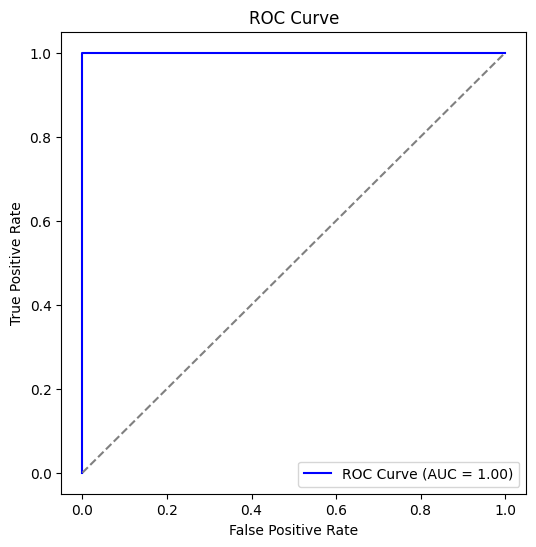

In [43]:
from sklearn.metrics import roc_curve

# ROC 곡선 계산
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# 그래프 그리기
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(auc_score))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### **결과 해석**

1. **정확도 (Accuracy)**: 모델이 전체 데이터에서 올바르게 분류한 비율을 나타낸다.
  - 1 이므로 모델 분류가 100% 정확한 것으로 보임
2. **AUC 점수**: 모델의 예측 확률이 얼마나 신뢰할 수 있는지 평가 (1에 가까울수록 우수)
  - 모든 이메일 반응을 100% 정확히 예측할 수 있음을 의미
3. **혼동 행렬 (Confusion Matrix)**: 실제 정답과 예측 결과 비교
4. **ROC 커브**: 모델이 얼마나 효과적으로 양성/음성을 구분하는지 시각적으로 확인


### **비즈니스 인사이트**

- 과거 이메일 오픈 비율(`past_open_rate`)과 응답 시간(`avg_response_time`)이 중요한 요인으로 작용할 가능성이 있음
- 이메일을 많이 받은 고객이 이메일을 열 가능성이 더 낮거나, 반대로 충성 고객일 경우 열 가능성이 높을 수도 있음
  - 각 고객에게 발송한 이메일 건수와 열람 여부를 확인하고, 특정 기간 내에 특정 빈도 이상으로 이메일 발송 시 미열람이 반복되는지 확인할 필요 있음
  - 이를 확인한 후 미열람이 지속되기 전 발송 빈도수를 적절한 이메일 발송 건수로 결정, 고객 특성을 고려해 기간별 이메일 발송 건수 조절 가능
- 이메일 반응 가능성이 높은 고객에게는 적극적인 마케팅을 적용하고, 반응이 낮은 고객에게는 다른 채널(SMS, 전화 등)을 고려 가능
- 고객 세그먼트가 100% 가능함을 의미하므로, 고객 커스텀 이메일 마케팅 진행
  - 고객의 전환이 이뤄질 만한 내용의 메일만을 간추려 발송하도록 설정
  - 키워드, 할인 프로모션 정보 등을 포함한 제목 사용
- 이메일 마케팅 캠페인에 대한 비용 최적화
  - 인풋, 아웃풋이 명확하므로, 과도/과소한 비용 배분은 좋지 않음



---

### **구독 기간 예측 (회귀 모델 적용)**

C사는 온라인 구독 서비스를 운영하고 있으며, 신규 가입자의 초기 사용 패턴을 바탕으로 얼마나 오랫동안 구독을 유지할지를 예측하고자 한다. 이를 통해 구독 기간이 짧을 가능성이 높은 고객을 사전에 파악하여 맞춤형 혜택(할인 쿠폰, 추가 콘텐츠 제공 등)을 제공할 수 있다.

**목표**

- 신규 가입자의 초기 사용 데이터를 바탕으로 구독 기간(일)을 예측
- 회귀 모델(선형 회귀)을 활용하여 특정 고객이 평균적으로 몇 일 동안 구독할지를 예측
- 예측된 결과를 기반으로 고객 유지 전략을 최적화



### **2. 데이터 설명**

**사용할 데이터 예시**

- **고객 특성 데이터**
    - `age` (나이)
    - `num_logins` (가입 후 첫 7일 동안 로그인 횟수)
    - `num_watched_videos` (첫 7일 동안 시청한 영상 수)
    - `avg_watch_time` (평균 시청 시간(분))
    - `subscription_length` (실제 구독 유지 기간(일), 회귀 모델의 타겟 변수)



### **3. 코드 작성 (회귀 모델 적용 및 예측 예제)**

### **필요 라이브러리 설치 및 데이터 준비**

In [48]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 63.5 MB/s eta 0:00:00


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 가상의 신규 구독자 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'num_logins': [2, 15, 3, 10, 20, 12, 5, 9, 18, 4,
                   8, 11, 6, 13, 22, 14, 7, 10, 19, 5],
    'num_watched_videos': [1, 10, 2, 7, 15, 9, 3, 6, 13, 2,
                            5, 8, 3, 9, 18, 11, 4, 7, 14, 4],
    'avg_watch_time': [5, 40, 8, 30, 60, 35, 12, 28, 50, 6,
                       18, 32, 10, 33, 70, 45, 9, 29, 55, 14],
    'subscription_length': [10, 45, 14, 30, 60, 50, 21, 35, 55, 12,
                            28, 40, 18, 42, 70, 48, 15, 37, 58, 20]  # 타겟 변수
}

df = pd.DataFrame(data)

# 데이터 분할 (독립변수 X, 종속변수 y)
X = df[['age', 'num_logins', 'num_watched_videos', 'avg_watch_time']]
y = df['subscription_length']

# 훈련 데이터와 테스트 데이터로 분할 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화 (회귀 모델의 입력값을 표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### **선형 회귀 모델 훈련 및 평가**

In [45]:
# 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 성능 평가
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print(f"MAE (평균 절대 오차): {mae:.2f}")
print(f"MSE (평균 제곱 오차): {mse:.2f}")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:.2f}")
print(f"R² (결정 계수): {r2:.2f}")


MAE (평균 절대 오차): 1.40
MSE (평균 제곱 오차): 3.32
RMSE (제곱근 평균 제곱 오차): 1.82
R² (결정 계수): 0.99


### **예측 결과 시각화**

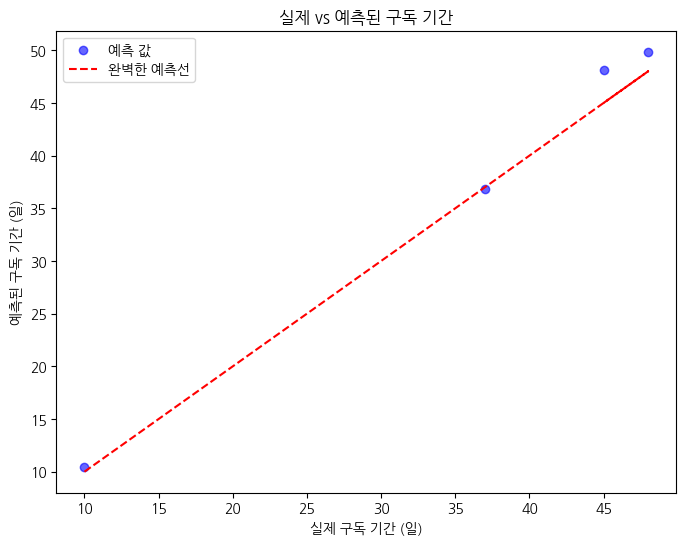

In [49]:
# 실제 값 vs 예측 값 비교 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='예측 값')
plt.plot(y_test, y_test, color='red', linestyle='--', label='완벽한 예측선')
plt.xlabel("실제 구독 기간 (일)")
plt.ylabel("예측된 구독 기간 (일)")
plt.title("실제 vs 예측된 구독 기간")
plt.legend()
plt.show()

### **예측 예제**

새로운 고객 데이터를 입력하여 예상 구독 기간을 예측해 보자.

In [47]:
# 새로운 고객 데이터 예측
new_customer = np.array([[27, 8, 5, 20]])  # [나이, 로그인 수, 시청한 영상 수, 평균 시청 시간]
new_customer_scaled = scaler.transform(new_customer)

# 예측 결과 출력
predicted_subscription_length = model.predict(new_customer_scaled)
print(f"예측된 구독 기간: {predicted_subscription_length[0]:.2f} 일")


예측된 구독 기간: 21.03 일


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names


### **결과 해석**

1. **평균 절대 오차 (MAE)**: 예측값과 실제값 간의 평균적인 차이
2. **평균 제곱 오차 (MSE)**: 오차의 제곱 평균(큰 오차에 민감)
3. **제곱근 평균 제곱 오차 (RMSE)**: MSE를 제곱근한 값 (오차의 실제 단위를 가짐)
4. **결정 계수 (R²)**: 모델의 설명력 (1에 가까울수록 우수)



### **비즈니스 인사이트**

- `num_logins` (로그인 횟수)와 `num_watched_videos` (시청한 영상 수)가 많을수록 구독 기간이 길어지는 경향이 있음
- `avg_watch_time` (평균 시청 시간)이 길수록 구독 유지 가능성이 높음
- 예측된 결과를 활용하여 구독 기간이 짧을 가능성이 높은 고객에게 혜택을 제공하는 전략을 고려 가능

- 고객 맞춤 추천 콘텐츠의 알고리즘 구체화 필요
  - 시청 시간대와 함께 분석하여 관심 콘텐츠 구분
- 구독 기간 짧은 고객들 대상 설문조사 진행
  - 콘텐츠 부족, 불편한 UX, 비싼 구독료 등의 원인 분석 필요
- 구독 기간 짧은 고객과 긴 고객을 구분하여 혜택 프로모션 진행
  - short: 체험 무료 기간
  - long: 3개월 이상 구독 유지 고객에게 다음 달 15% 할인 쿠폰 지급



---

### **고객 활동 기반 구독 플랜 추천 (다중 클래스 예측)**

D사는 여러 개의 구독 플랜(베이직, 스탠다드, 프리미엄)을 제공하는 온라인 서비스 플랫폼을 운영하고 있다. 신규 가입자가 첫 7일 동안 보여주는 행동 패턴을 바탕으로, 그들이 최종적으로 어떤 구독 플랜을 선택할 가능성이 높은지 예측하고자 한다. 이를 통해, 고객 맞춤형 마케팅 전략을 수립하고 적절한 프로모션을 제공할 수 있다.

**목표**

- 신규 가입자의 초기 사용 데이터를 바탕으로 최종적으로 선택할 구독 플랜을 예측
- 다중 클래스 분류 모델(소프트맥스 로지스틱 회귀)을 활용하여 고객이 베이직, 스탠다드, 프리미엄 중 어떤 플랜을 선택할지 예측
- 예측된 결과를 기반으로 구독 플랜별 맞춤 마케팅 전략을 최적화


### **2. 데이터 설명**

**사용할 데이터 예시**

- **고객 특성 데이터**
    - `age` (나이)
    - `num_logins` (가입 후 첫 7일 동안 로그인 횟수)
    - `num_watched_videos` (첫 7일 동안 시청한 영상 수)
    - `avg_watch_time` (평균 시청 시간(분))
    - `subscription_plan` (최종 구독 플랜: 0=베이직, 1=스탠다드, 2=프리미엄)


### **3. 코드 작성 (다중 클래스 로지스틱 회귀 적용 및 예측 예제)**

### **필요 라이브러리 설치 및 데이터 준비**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 가상의 고객 구독 플랜 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'num_logins': [2, 15, 3, 10, 20, 12, 5, 9, 18, 4,
                   8, 11, 6, 13, 22, 14, 7, 10, 19, 5],
    'num_watched_videos': [1, 10, 2, 7, 15, 9, 3, 6, 13, 2,
                            5, 8, 3, 9, 18, 11, 4, 7, 14, 4],
    'avg_watch_time': [5, 40, 8, 30, 60, 35, 12, 28, 50, 6,
                       18, 32, 10, 33, 70, 45, 9, 29, 55, 14],
    'subscription_plan': [0, 1, 0, 1, 2, 1, 0, 1, 2, 0,
                          1, 1, 0, 1, 2, 1, 0, 1, 2, 0]  # 다중 클래스 (0=베이직, 1=스탠다드, 2=프리미엄)
}

df = pd.DataFrame(data)

# 데이터 분할 (독립변수 X, 종속변수 y)
X = df[['age', 'num_logins', 'num_watched_videos', 'avg_watch_time']]
y = df['subscription_plan']

# 훈련 데이터와 테스트 데이터로 분할 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 정규화 (로지스틱 회귀는 입력 스케일에 민감)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### **다중 클래스 로지스틱 회귀 모델 훈련 및 평가**

In [51]:
# 다중 클래스 로지스틱 회귀 모델 생성 (Softmax Regression)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# 결과 출력
print(f"모델 정확도: {accuracy:.2f}")
print("혼동 행렬:")
print(conf_matrix)
print("분류 보고서:")
print(report)


모델 정확도: 0.75
혼동 행렬:
[[1 0 0]
 [1 1 0]
 [0 0 1]]
분류 보고서:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.83      0.83      0.78         4
weighted avg       0.88      0.75      0.75         4



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


### **시각화: 혼동 행렬**

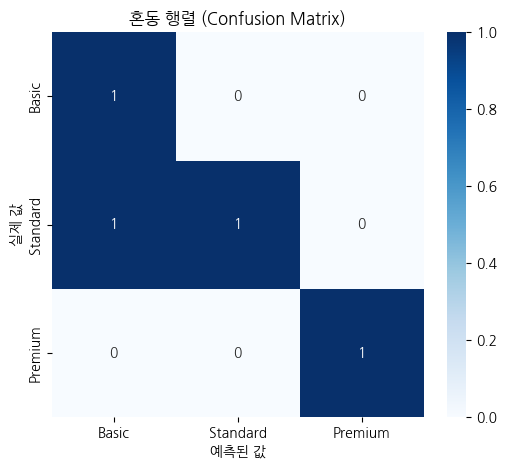

In [52]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Basic', 'Standard', 'Premium'], yticklabels=['Basic', 'Standard', 'Premium'])
plt.xlabel("예측된 값")
plt.ylabel("실제 값")
plt.title("혼동 행렬 (Confusion Matrix)")
plt.show()

### **예측 예제**

새로운 고객 데이터를 입력하여 예상 구독 플랜을 예측해 보자.

In [53]:
# 새로운 고객 데이터 예측
new_customer = np.array([[27, 8, 5, 20]])  # [나이, 로그인 수, 시청한 영상 수, 평균 시청 시간]
new_customer_scaled = scaler.transform(new_customer)

# 예측 결과 출력
predicted_plan = model.predict(new_customer_scaled)[0]
predicted_proba = model.predict_proba(new_customer_scaled)

plan_names = {0: "베이직", 1: "스탠다드", 2: "프리미엄"}
print(f"예측된 구독 플랜: {plan_names[predicted_plan]}")
print(f"각 구독 플랜 선택 확률: 베이직={predicted_proba[0][0]:.2f}, 스탠다드={predicted_proba[0][1]:.2f}, 프리미엄={predicted_proba[0][2]:.2f}")

예측된 구독 플랜: 베이직
각 구독 플랜 선택 확률: 베이직=0.63, 스탠다드=0.36, 프리미엄=0.01


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names


### **결과 해석**

1. **정확도 (Accuracy)**: 모델이 올바르게 예측한 비율
2. **혼동 행렬 (Confusion Matrix)**: 실제 구독 플랜과 예측된 값 비교
3. **분류 보고서 (Classification Report)**: 클래스별 정밀도, 재현율, F1 점수 제공
4. **예측 예제**: 특정 고객의 행동 데이터를 입력하면, 가장 적절한 구독 플랜을 예측하고 각 플랜별 확률을 제공


### **비즈니스 인사이트**

- `num_logins`, `num_watched_videos`, `avg_watch_time`가 높을수록 상위 플랜(프리미엄) 선택 확률이 높음
- 신규 고객 중 `베이직` 플랜을 선택할 가능성이 높은 고객에게 스탠다드 업그레이드 혜택 제공 가능
- `스탠다드` 플랜 고객 중 프리미엄 이동 가능성이 있는 고객에게 추가 혜택(추가 콘텐츠, 무료 체험 제공) 제공



---

### **1. 비즈니스 시나리오: 고객 충성도 등급 예측**

E사는 고객 데이터를 활용하여 고객의 충성도를 예측하고, 이를 기반으로 맞춤형 마케팅 전략을 수립하려 한다. 고객을 다음 세 가지 충성도 등급으로 분류한다.

- **0 (낮음)**: 구매 빈도가 낮고, 재방문 가능성이 낮음
- **1 (중간)**: 일정 수준의 구매와 재방문 기록이 있음
- **2 (높음)**: 높은 구매 빈도와 충성도를 보이며, 장기 고객이 될 가능성이 큼

고객의 연령, 월 평균 구매 횟수, 월 평균 구매 금액, 고객 서비스 문의 횟수 등의 정보를 바탕으로 충성도 등급을 예측하는 다중 클래스 분류 모델을 구축한다.


### **2. 다중 클래스 로지스틱 회귀 코드**

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 가상의 고객 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'monthly_purchases': [1, 5, 2, 3, 6, 4, 2, 3, 5, 1, 3, 4, 2, 4, 6, 5, 2, 3, 5, 2],
    'monthly_spending': [50, 300, 80, 200, 400, 250, 100, 220, 380, 60, 180, 240, 90, 270, 420, 320, 75, 230, 390, 110],
    'customer_support_calls': [3, 1, 4, 2, 0, 1, 3, 2, 0, 4, 2, 1, 3, 1, 0, 1, 4, 2, 0, 3],
    'loyalty_level': [0, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 0]  # 0=낮음, 1=중간, 2=높음
}

df = pd.DataFrame(data)

# 독립 변수(X)와 종속 변수(y) 분리
X = df[['age', 'monthly_purchases', 'monthly_spending', 'customer_support_calls']]
y = df['loyalty_level']

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 다중 클래스 로지스틱 회귀 모델 학습
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# 예측 함수 정의
def predict_loyalty(age, monthly_purchases, monthly_spending, customer_support_calls):
    """ 입력값을 받아 고객 충성도 등급을 예측 """
    input_data = np.array([[age, monthly_purchases, monthly_spending, customer_support_calls]])
    input_scaled = scaler.transform(input_data)

    predicted_class = model.predict(input_scaled)[0]
    predicted_proba = model.predict_proba(input_scaled)

    loyalty_labels = {0: "낮음", 1: "중간", 2: "높음"}

    print(f"\n🔹 예측된 고객 충성도 등급: {loyalty_labels[predicted_class]}")
    print(f"🔹 각 등급 확률: 낮음={predicted_proba[0][0]:.2f}, 중간={predicted_proba[0][1]:.2f}, 높음={predicted_proba[0][2]:.2f}")

# 예측 예제 실행
predict_loyalty(30, 4, 200, 2)  # 나이=30, 월 평균 구매=4회, 월 평균 구매액=200, 고객센터 문의=2회



🔹 예측된 고객 충성도 등급: 중간
🔹 각 등급 확률: 낮음=0.21, 중간=0.73, 높음=0.06


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names


### **사용 방법**

1. `predict_loyalty(age, monthly_purchases, monthly_spending, customer_support_calls)` 함수에 입력값을 전달하면 예측 수행
2. 예측된 **고객 충성도 등급 (낮음/중간/높음)** 을 출력
3. 각 등급에 대한 **예측 확률** 도 함께 표시

### **1. `app.py`**

Flask 서버를 구축하여 웹에서 고객 데이터를 입력하면 충성도 등급을 예측하는 API를 제공합니다.

In [55]:
display(df)

,age,monthly_purchases,monthly_spending,customer_support_calls,loyalty_level
0,22,1,50,3,0
1,45,5,300,1,2
2,25,2,80,4,0
3,33,3,200,2,1
4,50,6,400,0,2
5,41,4,250,1,1
6,29,2,100,3,0
7,39,3,220,2,1
8,48,5,380,0,2
9,23,1,60,4,0


In [ ]:
from flask import Flask, request, jsonify, render_template
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

app = Flask(__name__)

# 가상의 고객 데이터 생성
data = {
    'age': [22, 45, 25, 33, 50, 41, 29, 39, 48, 23, 31, 36, 27, 40, 53, 44, 26, 38, 51, 30],
    'monthly_purchases': [1, 5, 2, 3, 6, 4, 2, 3, 5, 1, 3, 4, 2, 4, 6, 5, 2, 3, 5, 2],
    'monthly_spending': [50, 300, 80, 200, 400, 250, 100, 220, 380, 60, 180, 240, 90, 270, 420, 320, 75, 230, 390, 110],
    'customer_support_calls': [3, 1, 4, 2, 0, 1, 3, 2, 0, 4, 2, 1, 3, 1, 0, 1, 4, 2, 0, 3],
    'loyalty_level': [0, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 0]  # 0=낮음, 1=중간, 2=높음
}

df = pd.DataFrame(data)

# 데이터 분할
X = df[['age', 'monthly_purchases', 'monthly_spending', 'customer_support_calls']]
y = df['loyalty_level']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 로지스틱 회귀 모델 학습
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 폼에서 받은 데이터
        age = float(request.form['age'])
        monthly_purchases = float(request.form['monthly_purchases'])
        monthly_spending = float(request.form['monthly_spending'])
        customer_support_calls = float(request.form['customer_support_calls'])

        # 입력 데이터 변환 및 예측
        input_data = np.array([[age, monthly_purchases, monthly_spending, customer_support_calls]])
        input_scaled = scaler.transform(input_data)
        predicted_class = model.predict(input_scaled)[0]
        predicted_proba = model.predict_proba(input_scaled)[0]

        loyalty_labels = {0: "낮음", 1: "중간", 2: "높음"}
        result = {
            "predicted_class": loyalty_labels[predicted_class],
            "probabilities": {
                "낮음": round(predicted_proba[0], 2),
                "중간": round(predicted_proba[1], 2),
                "높음": round(predicted_proba[2], 2)
            }
        }

        return jsonify(result)

    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001, debug=True)

### **2. templates/index.html**

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>고객 충성도 예측</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f4f4;
            text-align: center;
            padding: 20px;
        }
        .container {
            background: white;
            padding: 20px;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
            max-width: 400px;
            margin: auto;
        }
        input, button {
            width: 90%;
            padding: 10px;
            margin: 5px 0;
            border: 1px solid #ccc;
            border-radius: 5px;
        }
        button {
            background-color: #28a745;
            color: white;
            border: none;
            cursor: pointer;
        }
        button:hover {
            background-color: #218838;
        }
        .result {
            margin-top: 15px;
            font-weight: bold;
        }
    </style>
</head>
<body>

    <div class="container">
        <h2>고객 충성도 예측</h2>
        <form id="predict-form">
            <label>나이:</label>
            <input type="number" id="age" name="age" required>

            <label>월 평균 구매 횟수:</label>
            <input type="number" id="monthly_purchases" name="monthly_purchases" required>

            <label>월 평균 지출 금액:</label>
            <input type="number" id="monthly_spending" name="monthly_spending" required>

            <label>고객 서비스 문의 횟수:</label>
            <input type="number" id="customer_support_calls" name="customer_support_calls" required>

            <button type="submit">예측하기</button>
        </form>

        <div class="result" id="result"></div>
    </div>

    <script>
        document.getElementById("predict-form").addEventListener("submit", function(event) {
            event.preventDefault();

            let formData = new FormData(this);

            fetch("/predict", {
                method: "POST",
                body: formData
            })
            .then(response => response.json())
            .then(data => {
                if (data.error) {
                    document.getElementById("result").innerHTML = `<p style="color: red;">오류 발생: ${data.error}</p>`;
                } else {
                    document.getElementById("result").innerHTML = `
                        <p>예측된 고객 충성도: <strong>${data.predicted_class}</strong></p>
                        <p>낮음: ${data.probabilities.낮음}</p>
                        <p>중간: ${data.probabilities.중간}</p>
                        <p>높음: ${data.probabilities.높음}</p>
                    `;
                }
            })
            .catch(error => {
                document.getElementById("result").innerHTML = `<p style="color: red;">API 호출 오류: ${error}</p>`;
            });
        });
    </script>

</body>
</html>


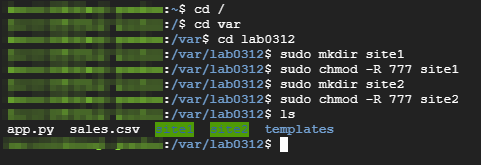

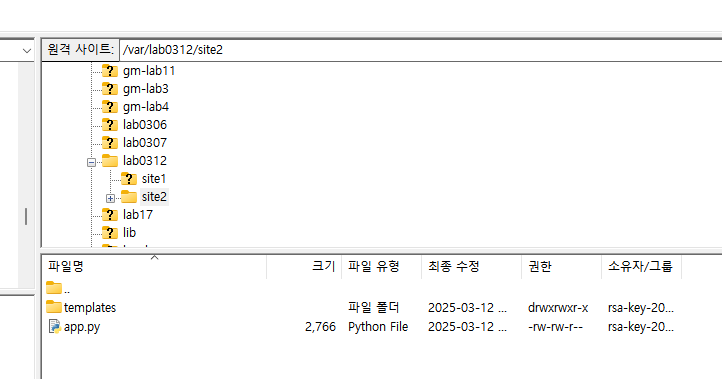

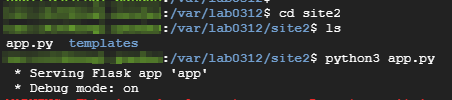

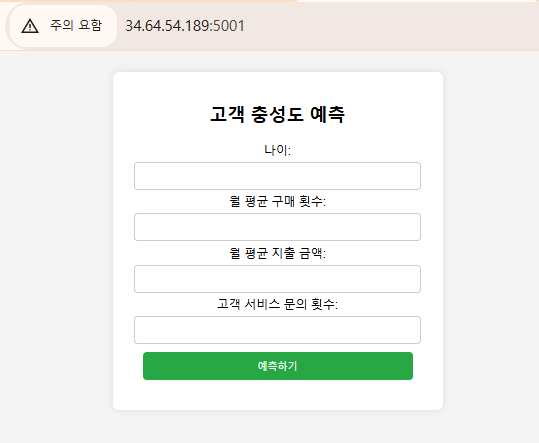

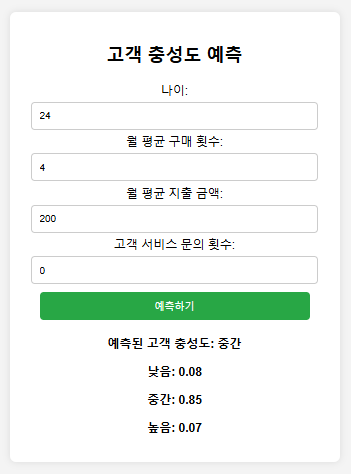